In [12]:
#K-medias es un algoritmo de agrupamiento por particiones cuyo objetivo es separar los objetos
#en K conjuntos disjuntos minimizando la suma de distancias al cuadrado de los objetos
#de cada grupo. 
#Importamos los datos
import pandas as pd
url_datos = 'https://drive.google.com/uc?id=1OzVlp4RsT63W6d18_Zc5WmUonLXMDNL8'
mexpr = pd.read_csv(url_datos, delimiter='\t')
mexpr_toy = mexpr.iloc[0:49, 0:19] #Coger un conjunto pequeño de los datos

print(f"Dimensiones originales: {mexpr.shape}")
mexpr_toy.head()

Dimensiones originales: (1500, 473)


,TCGA-D9-A4Z6-06,TCGA-EE-A2MQ-06,TCGA-EE-A3AF-06,TCGA-ER-A19F-06,TCGA-EE-A2MF-06,TCGA-EE-A2MJ-06,TCGA-BF-AAP4-01,TCGA-D3-A8GM-06,TCGA-GN-A26A-06,TCGA-EB-A3XE-01,TCGA-DA-A1I0-06,TCGA-FR-A3R1-01,TCGA-EE-A3AA-06,TCGA-W3-AA21-06,TCGA-D9-A6EA-06,TCGA-D3-A5GU-06,TCGA-EE-A29X-06,TCGA-EB-A4IS-01,TCGA-GF-A769-01
TYRP1,7.941545,2.750463,-5.566030,-4.907263,5.546815,7.036795,1.296667,8.453333,-4.295078,-2.822735,5.343145,-7.718614,-7.908148,4.485929,4.139340,-1.057352,-0.652172,6.943202,-5.958273
RPS4Y1,3.475878,-9.252088,-8.781994,-1.866586,-7.544166,0.983460,3.230248,1.556010,-8.687076,-8.216183,3.064411,2.580197,2.195396,-1.716290,2.127876,2.774703,-8.799704,0.504181,3.337378
KRT6A,-2.734785,0.420073,0.026095,0.850417,-2.374815,3.097854,2.583622,-2.734785,-1.190053,13.664241,-0.072284,-1.998570,6.665974,-2.734785,-1.937108,-2.734785,-0.754175,5.124605,-1.942097
XIST,-2.903056,8.320289,6.928525,-3.042341,9.475711,-3.487538,-2.690857,-3.487538,8.461294,6.168198,-3.487538,-1.380218,-1.269842,0.339875,-2.179177,-3.487538,6.039122,8.429310,-2.127342
KRT14,-3.653679,-2.898792,-0.531967,0.375261,-0.798866,1.482611,1.573041,-3.232954,0.714726,13.313004,-1.176080,-0.716749,4.210739,-3.653679,0.600907,-3.653679,-1.426185,6.348977,-2.152469


In [14]:
#Importamos librerias y definimos el algoritmo y sus parámetros
from sklearn.cluster import KMeans
from sklearn import metrics, preprocessing

datos = mexpr_toy.transpose()   #primero transponemos la matriz

#Estandarizamos (media=0, std=1)
scaler = preprocessing.StandardScaler()
datos_scaled=pd.DataFrame(
    scaler.fit_transform(datos),
    index=datos.index,
    columns=datos.columns
)
print(f"Forma de los datos para clustering: {datos_scaled.shape}")
print("(filas=muestras, columnas=genes)")

Forma de los datos para clustering: (19, 49)
(filas=muestras, columnas=genes)


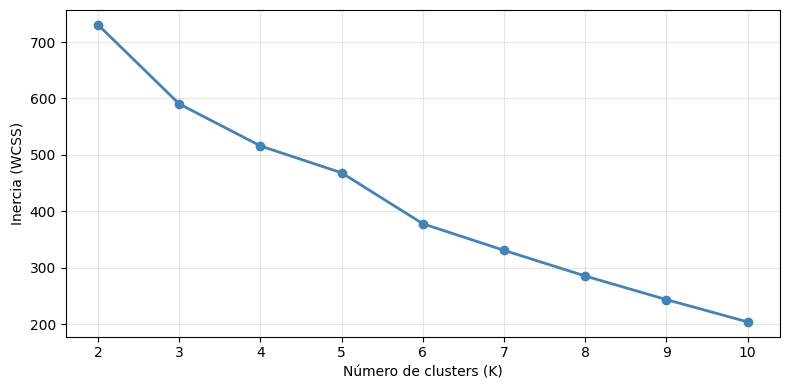

In [16]:
#Búsqueda del K óptimo: método del codo
import matplotlib.pyplot as plt
inercias = []
rango_k = range(2,11)
for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(datos_scaled)
    inercias.append(km.inertia_)

#Gráfico del codo
plt.figure(figsize=(8, 4))
plt.plot(rango_k, inercias, marker='o', linewidth=2, color='steelblue')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia (WCSS)')
plt.xticks(rango_k)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Primera forma de buscar el K óptimo. La gráfica superior muestra el método del codo, cuanta mayor sea la inercia (WCSS) más óptimo es el número de clusters. En este caso el número de clusters óptimo es 2. Sin embargo, lo podemos comprobar haciendo el Índice Silhouette

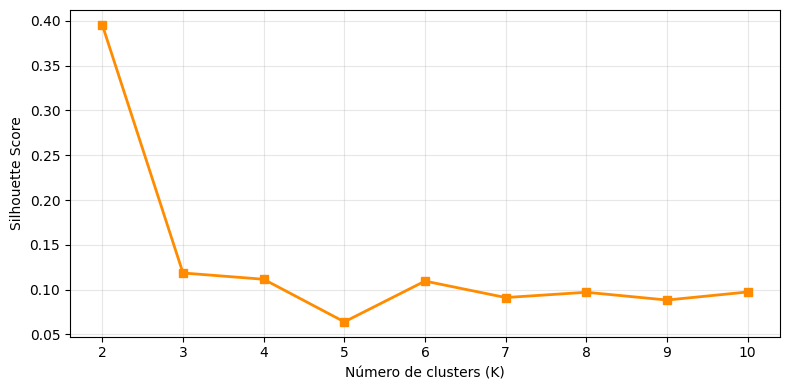

K óptimo según Silhouette: 2 (score = 0.395)


In [18]:
#Búsqueda del K óptimo: Índice Silhouette

silhouettes = []

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(datos_scaled)
    score = metrics.silhouette_score(datos_scaled, labels)
    silhouettes.append(score)

#Gráfico silhouette
plt.figure(figsize=(8,4))
plt.plot(rango_k, silhouettes, marker='s', linewidth=2, color='darkorange')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(rango_k)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

k_optimo = rango_k[silhouettes.index(max(silhouettes))]
print(f"K óptimo según Silhouette: {k_optimo} (score = {max(silhouettes):.3f})")

Otra forma de buscar el K óptimo. En la gráfica superior, se puede visualizar la puntuación del índice de silhouette en función del número de clusters. Cuanto mayor es el score (parte superior de la gráfica) más óptimo es la K.

In [20]:
#Clustering final con el K óptimo
k_means_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
cluster_predict = k_means_final.fit_predict(datos_scaled)

clusters = pd.DataFrame(cluster_predict, index=datos_scaled.index, columns=['cluster'])

print("Tamaño de cada cluster:")
print(clusters['cluster'].value_counts().sort_index())


Tamaño de cada cluster:
cluster
0     1
1    18
Name: count, dtype: int64


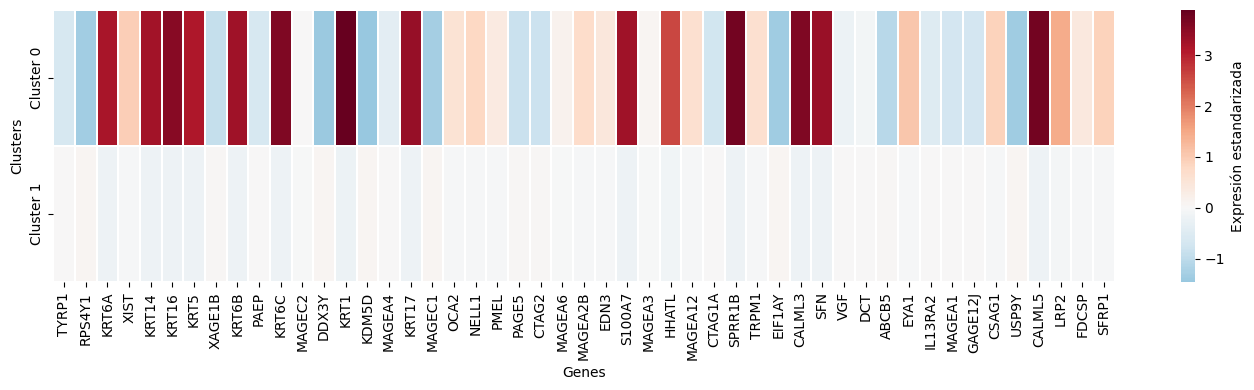

In [23]:
#Heatmap de centroides
import seaborn as sns
centers = pd.DataFrame(k_means_final.cluster_centers_, columns=datos_scaled.columns)
centers.index = [f'Cluster {i}' for i in centers.index]

plt.figure(figsize=(14,4))
sns.heatmap(centers, cmap='RdBu_r',
            center=0, linewidths=0.3,
            annot=False, yticklabels=True,
            xticklabels=True,
            cbar_kws={'label':'Expresión estandarizada'}
)
plt.xlabel('Genes')
plt.ylabel('Clusters')
plt.tight_layout()
plt.show()

In [ ]:
#Índices de bondad del clustering final
sil = metrics.silhouette_score(datos_scaled, cluster_predict)
ch = metrics.calinski_harabasz_score(datos_scaled, cluster_predict)
db = metrics.davies_bouldin_score(datos_scaled, cluster_predict)

print("=== Bondad del Clustering ===")
print(f" Silhouette Score   : {sil:.4f}")
print(f" Calinski-Harabasz  : {ch:.2f}")
print(f" Davies-Bouldin     : {db:.4f}")

=== Bondad del Clustering ===
 Silhouette Score   : 0.3954
 Calinski-Harabasz  : 4.66
 Davies-Bouldin     : 0.4316


Silhouette Score: El rango es de [-1,1], por lo que un valor positivo es buen indicio. Los clusters tienen cierta separación real pero hay algo de solapamiento. Para datos de expresión génica es habitual, ya que el ruido biológico hace difícil que haya una separación limpia.
Calinski-Harabasz: El rango es de [0,∞), por lo que se interpreta comparando entre distintos K. Este índice es el que más sufre con un dataset pequeño, podemos probar a dar más espacio.
Davies Bouldin: el rango ideal es [0,∞), donde a menor valor mejor es el resultado.